In [1]:
import scanpy as sc
import velot

adata = sc.read_h5ad("../article/data/Gastrulation/erythroid_velot.h5ad")

In [2]:
figures_path = "../article/figures/figure 4"
show = False
save = True
basis = "pca"
clusters_key = "celltype"

VelOT Velocity Metrics

Inner-Cluster Coherence (mean: 0.989):
        Blood progenitors 1: 0.988
        Blood progenitors 2: 0.991
                 Erythroid1: 0.991
                 Erythroid2: 0.989
                 Erythroid3: 0.985

Inner-Cluster Coherence (median: 0.990):
        Blood progenitors 1: 0.990
        Blood progenitors 2: 0.992
                 Erythroid1: 0.992
                 Erythroid2: 0.990
                 Erythroid3: 0.988

Cross-Boundary Correctness (mean: 0.942):
  Blood progenitors 1 → Blood progenitors 2: 0.953
  Blood progenitors 2 → Erythroid1     : 0.926
       Erythroid1 → Erythroid2     : 0.933
       Erythroid2 → Erythroid3     : 0.956


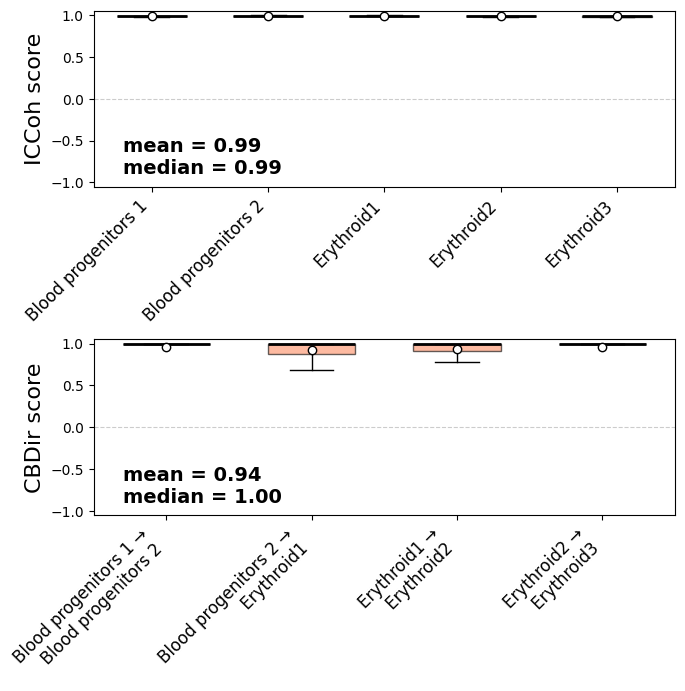

In [3]:
edges = [
    ('Blood progenitors 1', 'Blood progenitors 2'), 
    ('Blood progenitors 2', 'Erythroid1'),
    ('Erythroid1', 'Erythroid2'), 
    ('Erythroid2', 'Erythroid3')
]
results = velot.metrics.summary(adata, cluster_edges=edges, cluster_key=clusters_key, embedding_key=f"X_{basis}", velocity_key=f"velot_velocity_{basis}")
velot.pl.metric_summary(results, orientation="vertical", layout="column", figsize=(7,7), show=show, save=save, save_path=f"{figures_path}/figure4_h.png")

In [1]:
import velot
import numpy as np
import scanpy as sc
import scvelo as scv

# import os
# from pathlib import Path
# os.chdir(Path(__file__).resolve().parent)

figures_path = "../article/figures/figure aux"
show = True
save = False
basis = "pca"
project_umap = True if basis == "pca" else False
clusters_key = "clusters"

# Load data
# adata = sc.read_h5ad("../datasets/pancreas_velot.h5ad")
adata = sc.read_h5ad("../article/datasets/endocrinogenesis_day15.5_preprocessed.h5ad")

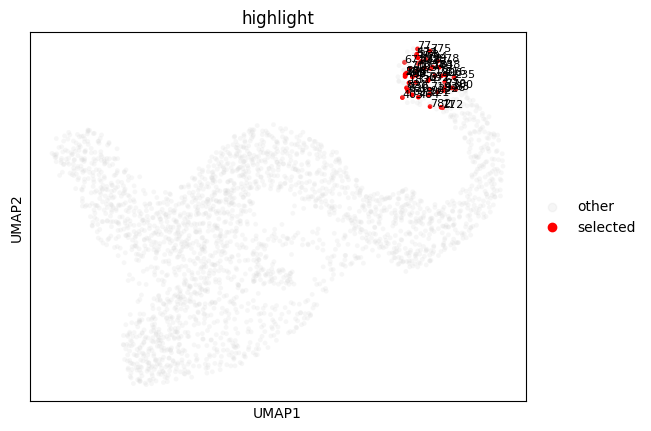

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

names = adata[adata.obs["clusters"] == "Ngn3 low EP"].obs_names.values

i = 0
n = 50
selected = names[i*n:(i+1)*n]

# Highlight selected cells
adata.obs["highlight"] = np.where(
    adata.obs_names.isin(selected),
    "selected",
    "other"
)

# Plot UMAP
ax = sc.pl.umap(
    adata,
    color="highlight",
    palette={"selected": "red", "other": "#d3d3d330"},
    show=False
)

# Get UMAP coordinates
coords = adata.obsm["X_umap"]

# Add labels
for cell in selected:
    idx = adata.obs_names.get_loc(cell)

    x = coords[idx, 0]
    y = coords[idx, 1]

    ax.text(
        x,
        y,
        str(idx),          # or use `cell` to show obs_name instead
        fontsize=8
    )

plt.show()

VelOT: Computing velocity field
  Basis: X_pca (10D)
  Cells: 2531
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Spatial clustering: 25 clusters via KMeans on X_pca (10D)
  Built 48 window pairs across 25 clusters (skipped 0 small clusters)
  Window size: 50, step: 50

[2/4] Computing OT velocity...
  OT velocity computed: 2106 cells with velocity, 425 cells without (will be filled by smoothing)

[3/4] Smoothing velocity field...
Found torch compatible version. Running on cuda device
    epoch 50/150: total=1.1917 reg=5.1528 smooth=0.0015 curl=0.0002
    epoch 100/150: total=1.0527 reg=4.6819 smooth=0.0009 curl=0.0001
    epoch 150/150: total=1.1721 reg=5.2095 smooth=0.0010 curl=0.0001
  Smoothing complete: final total=1.1721

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (2531 cells)
  Velocity projected to UMAP (2531 cells)

VelOT: Done.


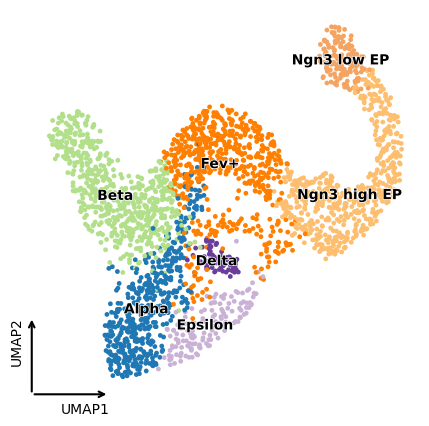

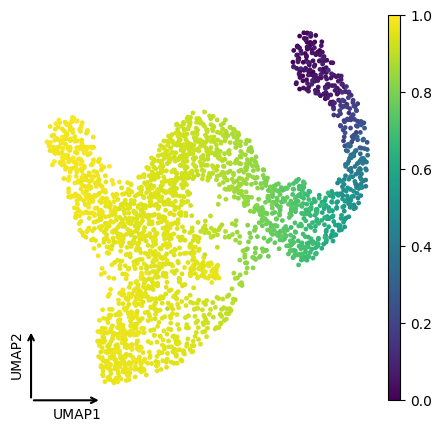

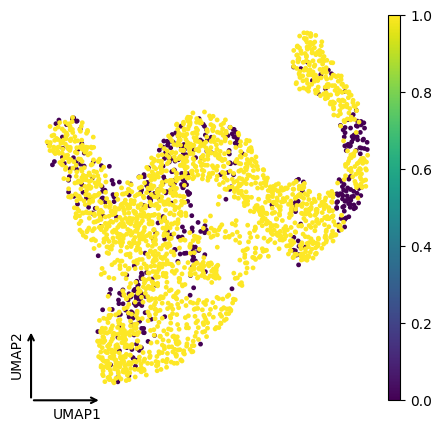

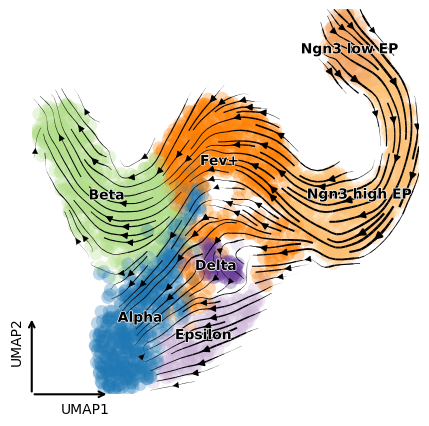

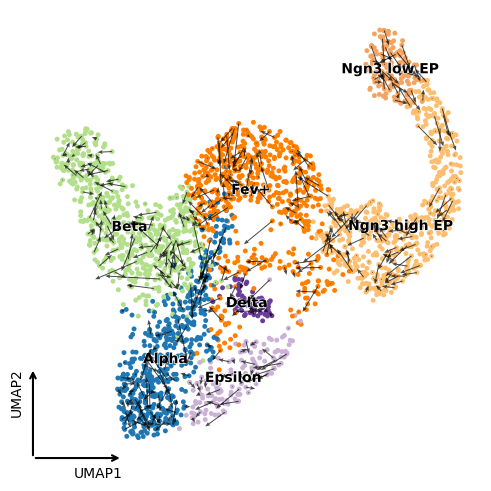

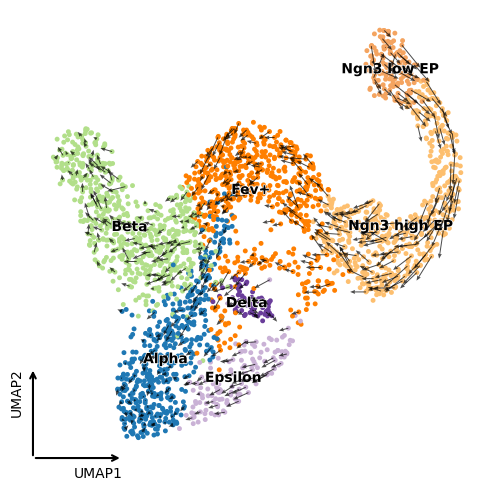

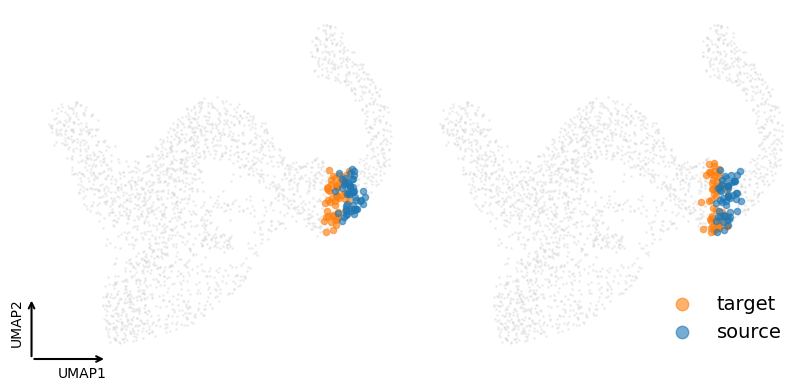

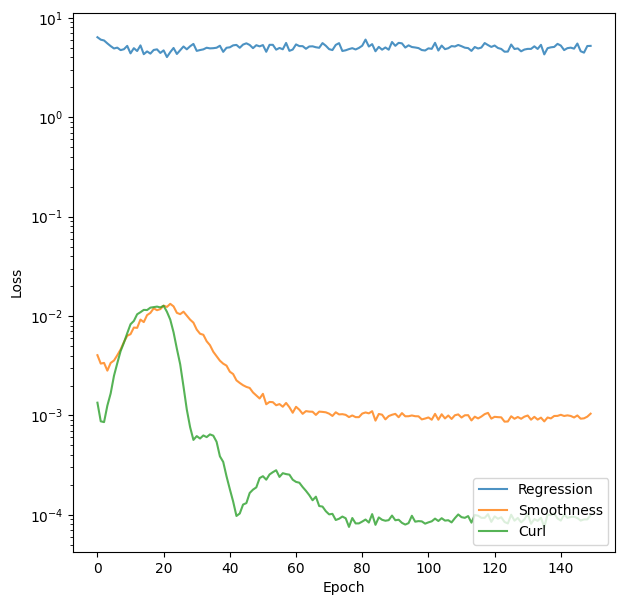

VelOT Velocity Metrics

Inner-Cluster Coherence (mean: 0.967):
                      Alpha: 0.939
                       Beta: 0.972
                      Delta: 0.974
                    Epsilon: 0.947
                       Fev+: 0.964
               Ngn3 high EP: 0.987
                Ngn3 low EP: 0.988

Inner-Cluster Coherence (median: 0.976):
                      Alpha: 0.948
                       Beta: 0.979
                      Delta: 0.976
                    Epsilon: 0.953
                       Fev+: 0.967
               Ngn3 high EP: 0.988
                Ngn3 low EP: 0.991

Cross-Boundary Correctness (mean: 0.875):
      Ngn3 low EP → Ngn3 high EP   : 0.949
     Ngn3 high EP → Fev+           : 0.834
             Fev+ → Delta          : 0.940
             Fev+ → Beta           : 0.919
             Fev+ → Epsilon        : 0.702
             Fev+ → Alpha          : 0.904


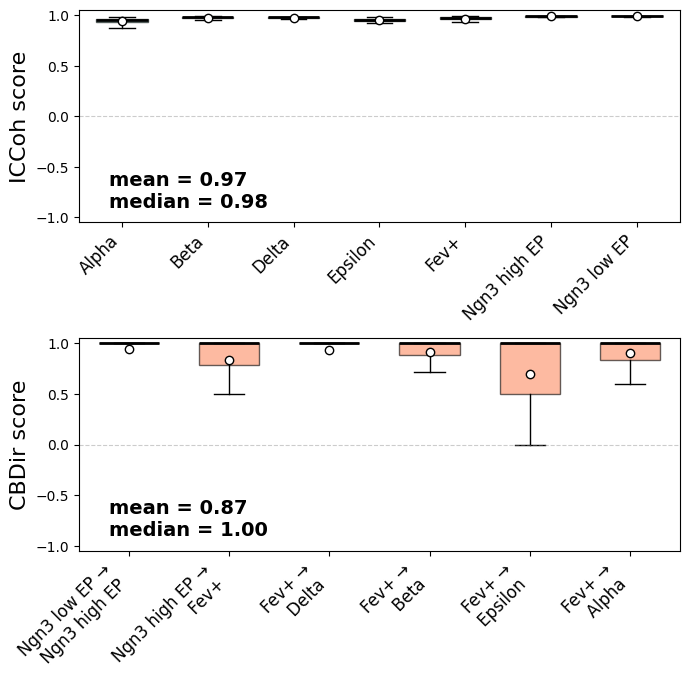

Found torch compatible version. Running on cuda device
  Starting cells: 159 candidates (pseudotime=[min, 0.100])
  Total: 30 trajectories (forward) from 'None'
  Using continuous velocity field (neural network)
  Forward — Terminal clusters: {np.str_('Alpha'): np.int64(6), np.str_('Beta'): np.int64(24)}


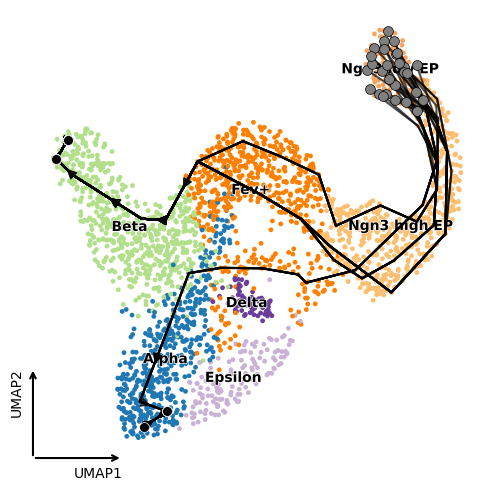

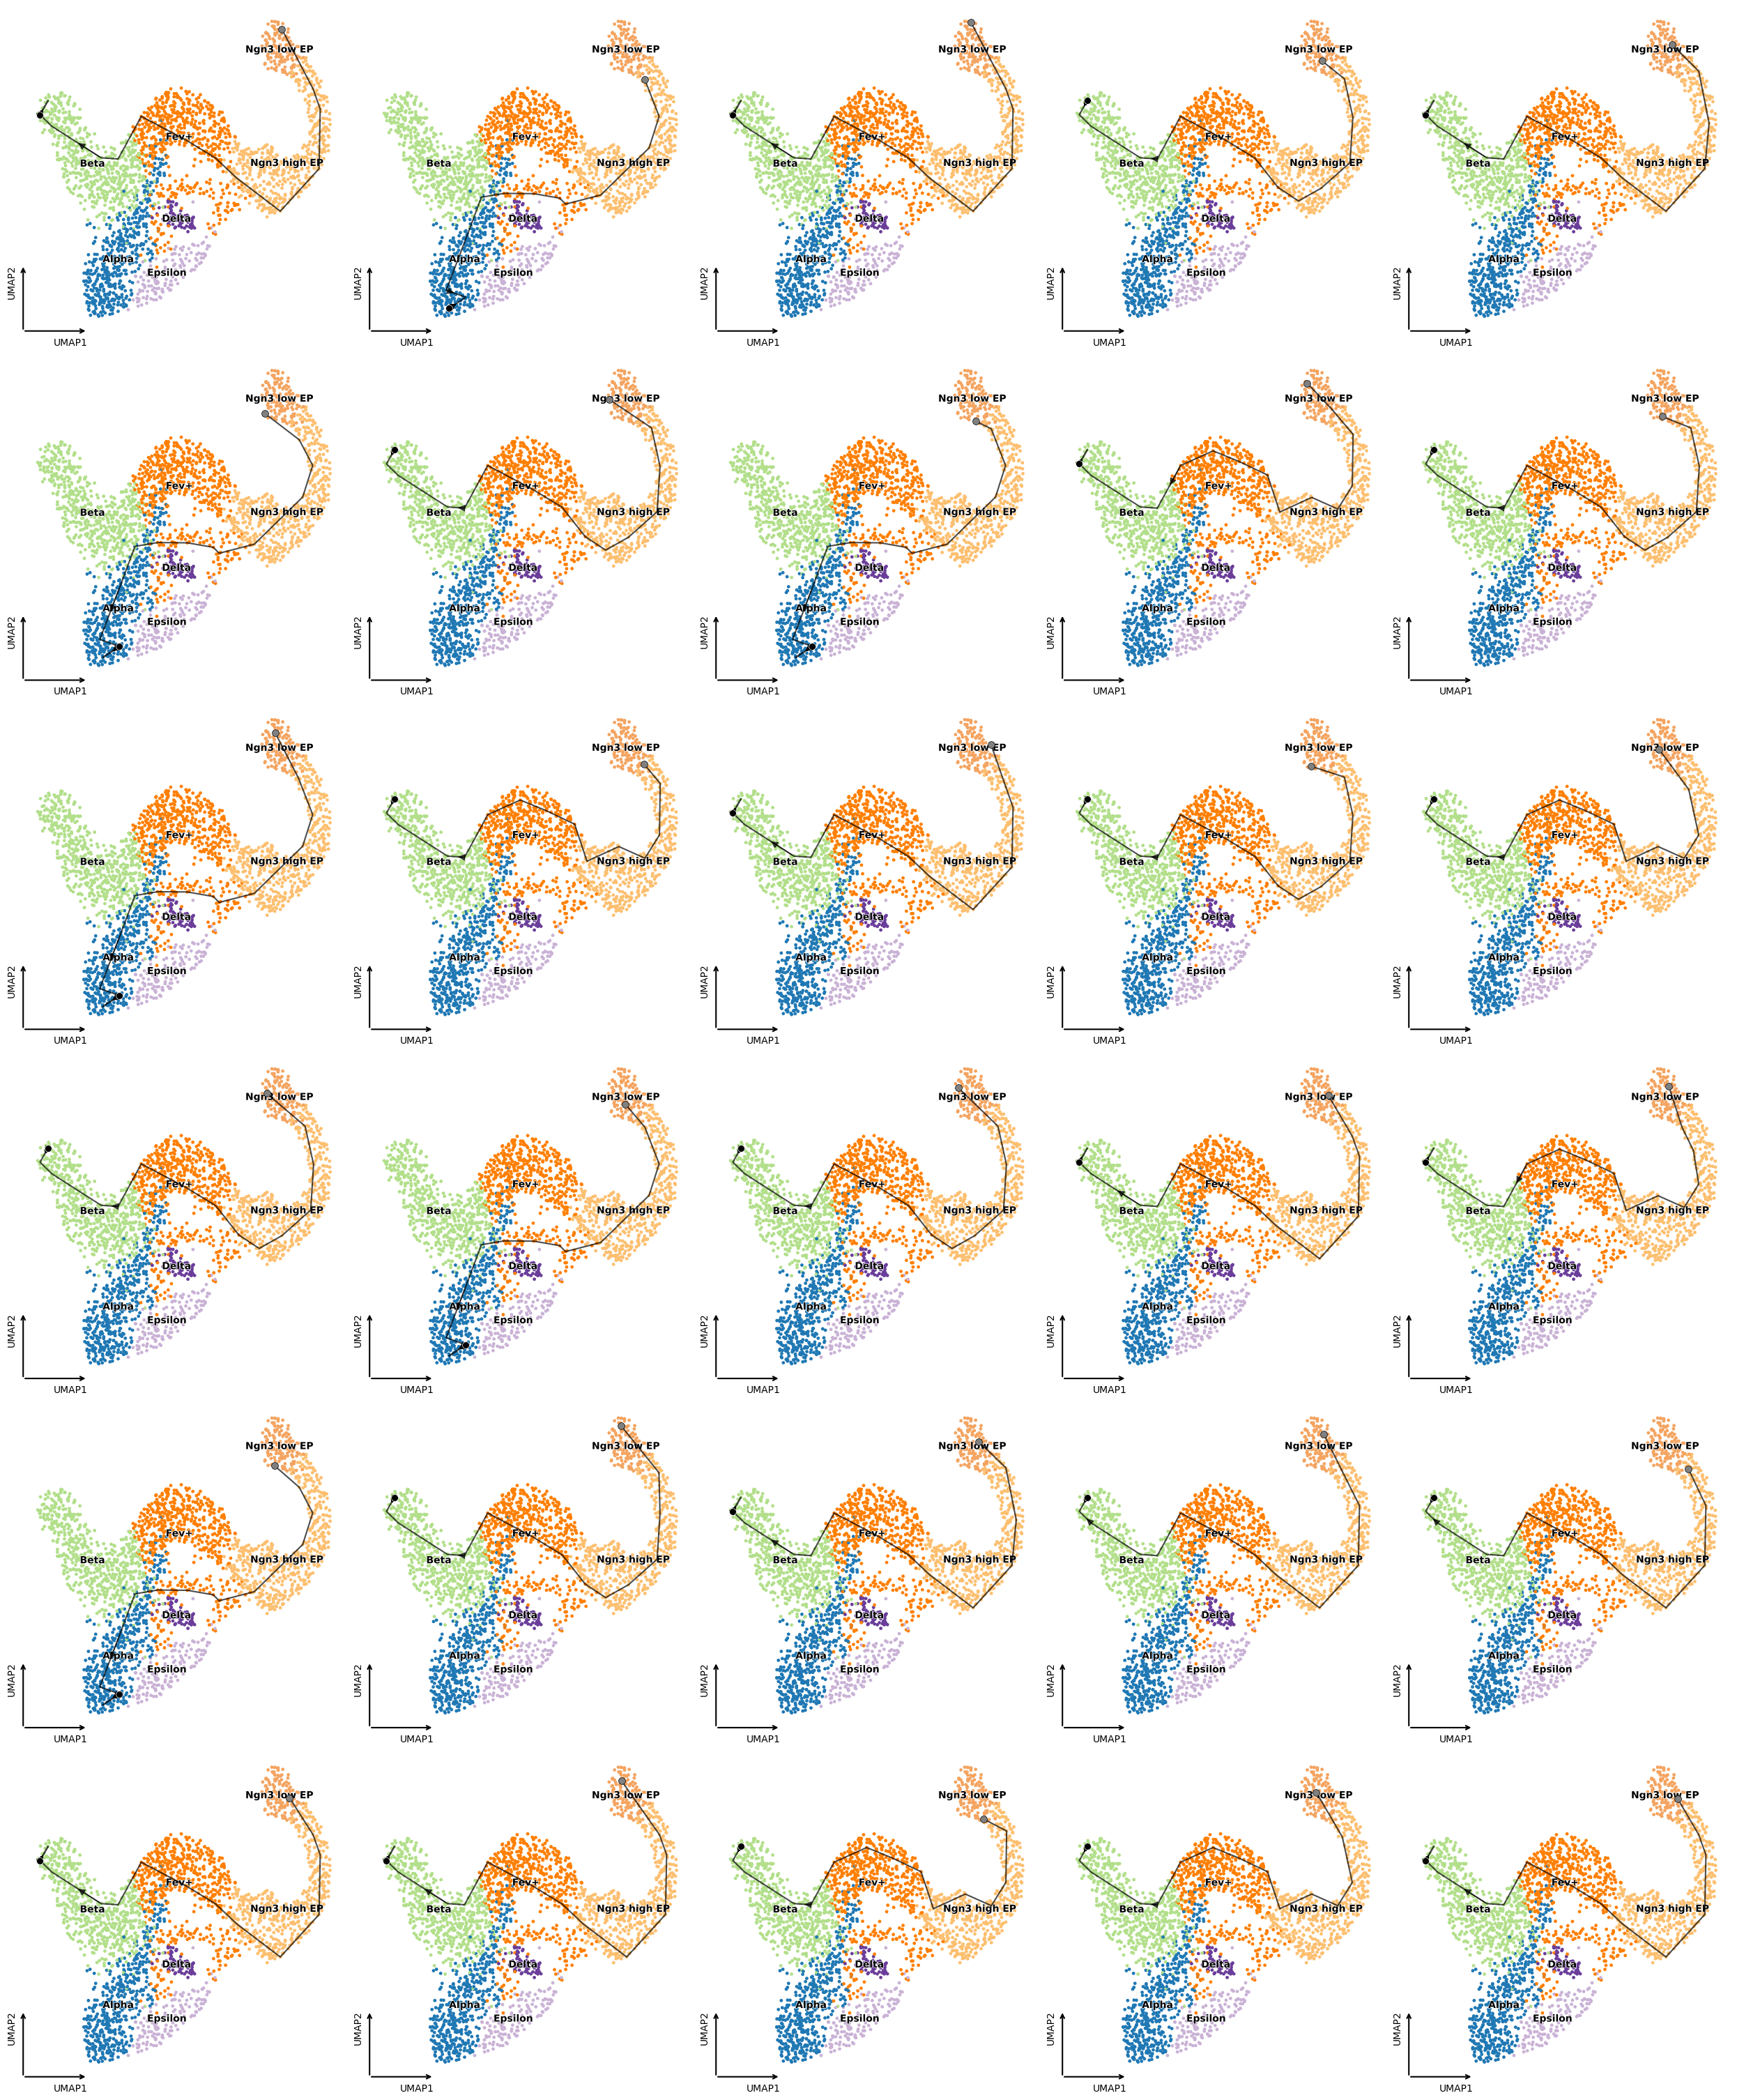

In [2]:

# Preprocess
velot.pp.pca(adata, n_pcs=10)
sc.pp.neighbors(adata, 20, use_rep="X_pca")
velot.pp.pseudotime(adata, root_cluster="Ngn3 low EP", root_cell=77) # cluster_key=clusters_key)
adata.obs["clusters_id"] = adata.obs[clusters_key].cat.codes

# Compute velocity (full pipeline)
velot.tl.velocity(
    adata=adata,
    basis=f"X_{basis}",
    smooth=True,
    n_clusters=None,
    window_size=50,
    overlap_fraction=0,
    # spatial_key="clusters_id",
    reg=0.1, lambda_time=1, n_epochs=150, lambda_smooth=0.7, lambda_curl=0.7, lambda_divergence=0,
    project_umap=project_umap
)

# Visualize
velot.pl.dataset_overview_simple(adata, color=clusters_key, title="", figsize=(5,5), inframe=True, out_legend=False, show=show, save=save, save_path=f"{figures_path}/figure2_a.png")
velot.pl.dataset_overview_simple(adata, color="pseudotime", title="", show=show, save=save, save_path=f"{figures_path}/figure2_b.png")
velot.pl.dataset_overview_simple(adata, color="velot_confidence", title="", show=show, save=save, save_path=f"{figures_path}/figure2_c.png")
velot.pl.velocity_stream(adata, color=clusters_key, title=None, figsize=(5,5), show=show, save=save, save_path=f"{figures_path}/figure2_d.png")
velot.pl.velocity_quiver(adata, color=clusters_key, basis="umap", title="", subsample=500, figsize=(5,5), velocity_key=f"velot_velocity_raw_umap", show=show, save=save, save_path=f"{figures_path}/figure2_e.png")
velot.pl.velocity_quiver(adata, color=clusters_key, basis="umap", title="", subsample=500, figsize=(5,5), velocity_key=f"velot_velocity_umap", show=show, save=save, save_path=f"{figures_path}/figure2_f.png")
# velot.pl.windows(adata, pairs_to_show=tuple([i for i in range(adata.uns["velot_windows"]["n_pairs"])]), figsize_per_panel=(4,4), show=show, save=save, save_path=f"{figures_path}/figure2_j.png")
velot.pl.windows(adata, pairs_to_show=[29,30], figsize_per_panel=(4,4), show=show, save=save, save_path=f"{figures_path}/figure2_j.png")
velot.pl.training_curves_single(adata, figsize=(7,7), show=show, save=save, save_path=f"{figures_path}/figure2_g.png")

# Evaluate
edges = [
    ('Ngn3 low EP', 'Ngn3 high EP'), 
    ('Ngn3 high EP', 'Fev+'),
    ('Fev+', 'Delta'), 
    ('Fev+', 'Beta'),
    ('Fev+','Epsilon'),
    ('Fev+','Alpha')
]
results = velot.metrics.summary(adata, cluster_edges=edges, cluster_key=clusters_key, embedding_key=f"X_{basis}", velocity_key=f"velot_velocity_{basis}")
velot.pl.metric_summary(results, orientation="vertical", layout="column", figsize=(7,7), show=show, save=save, save_path=f"{figures_path}/figure2_h.png")

# Trajectories using the continuous field with evolving pseudotime
velot.tl.compute_trajectories(
    adata,
    basis=f"X_{basis}",
    velocity_key=f"velot_velocity_{basis}",
    direction="forward",
    use_network=True,
    evolve_pseudotime=True,
    end_pseudotime=0.1,
    n_trajectories=30,
    cluster_key=clusters_key,
    n_steps=300, step_size=2
)
velot.pl.trajectories(
    adata, color=clusters_key, line_width=1.5, line_style="-", arrow_frequency=10, arrow_size=15,
    basis="umap", show=show, save=save, save_path=f"{figures_path}/figure2_i.png")

import matplotlib.pyplot as plt

n = 30
cols = 5
rows = n // 5 + 1
s = 5
fig, axes = plt.subplots(rows, cols, figsize=(s*cols,s*rows))
axes = axes.flatten()

for i in range(n):
    axes[i] = velot.pl.trajectories(
        adata, color=clusters_key, line_width=1.5, line_style="-", arrow_frequency=10, arrow_size=15,
        show=show, basis="umap", trajectory_ids=[i], ax=axes[i]
    )

# Hide unused subplots
for j in range(n, len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()

if save:
    adata.write("../article/datasets/pancreas_velot.h5ad")

In [3]:
# Trajectories using the continuous field with evolving pseudotime
basis = "pca"
start_cluster = "Alpha"
velot.tl.compute_trajectories(
    adata,
    basis=f"X_{basis}",
    velocity_key=f"velot_velocity_{basis}",
    direction="backward",
    use_network=False,
    evolve_pseudotime=True,
    start_cluster=start_cluster,
    # target_cluster="Fev +",
    n_trajectories=30,
    cluster_key=clusters_key,
    n_steps=300, step_size=2
)

Found torch compatible version. Running on cuda device
  Starting cells: 477 candidates (cluster='Alpha')
  Total: 30 trajectories (backward) from 'Alpha'
  Backward — Origin clusters: {np.str_('Ngn3 low EP'): np.int64(30)}


AnnData object with n_obs × n_vars = 2531 × 2000
    obs: 'day', 'proliferation', 'G2M_score', 'S_score', 'phase', 'clusters_coarse', 'clusters', 'clusters_fine', 'louvain_Alpha', 'louvain_Beta', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'dpt_pseudotime', 'pseudotime', 'clusters_id', 'velot_spatial_cluster', 'velot_confidence'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'clusters_colors', 'clusters_fine_colors', 'diffmap_evals', 'iroot', 'louvain_Alpha_colors', 'louvain_Beta_colors', 'neighbors', 'pca', 'recover_dynamics', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'velot_windows', 'velot_smoothing', 'vel

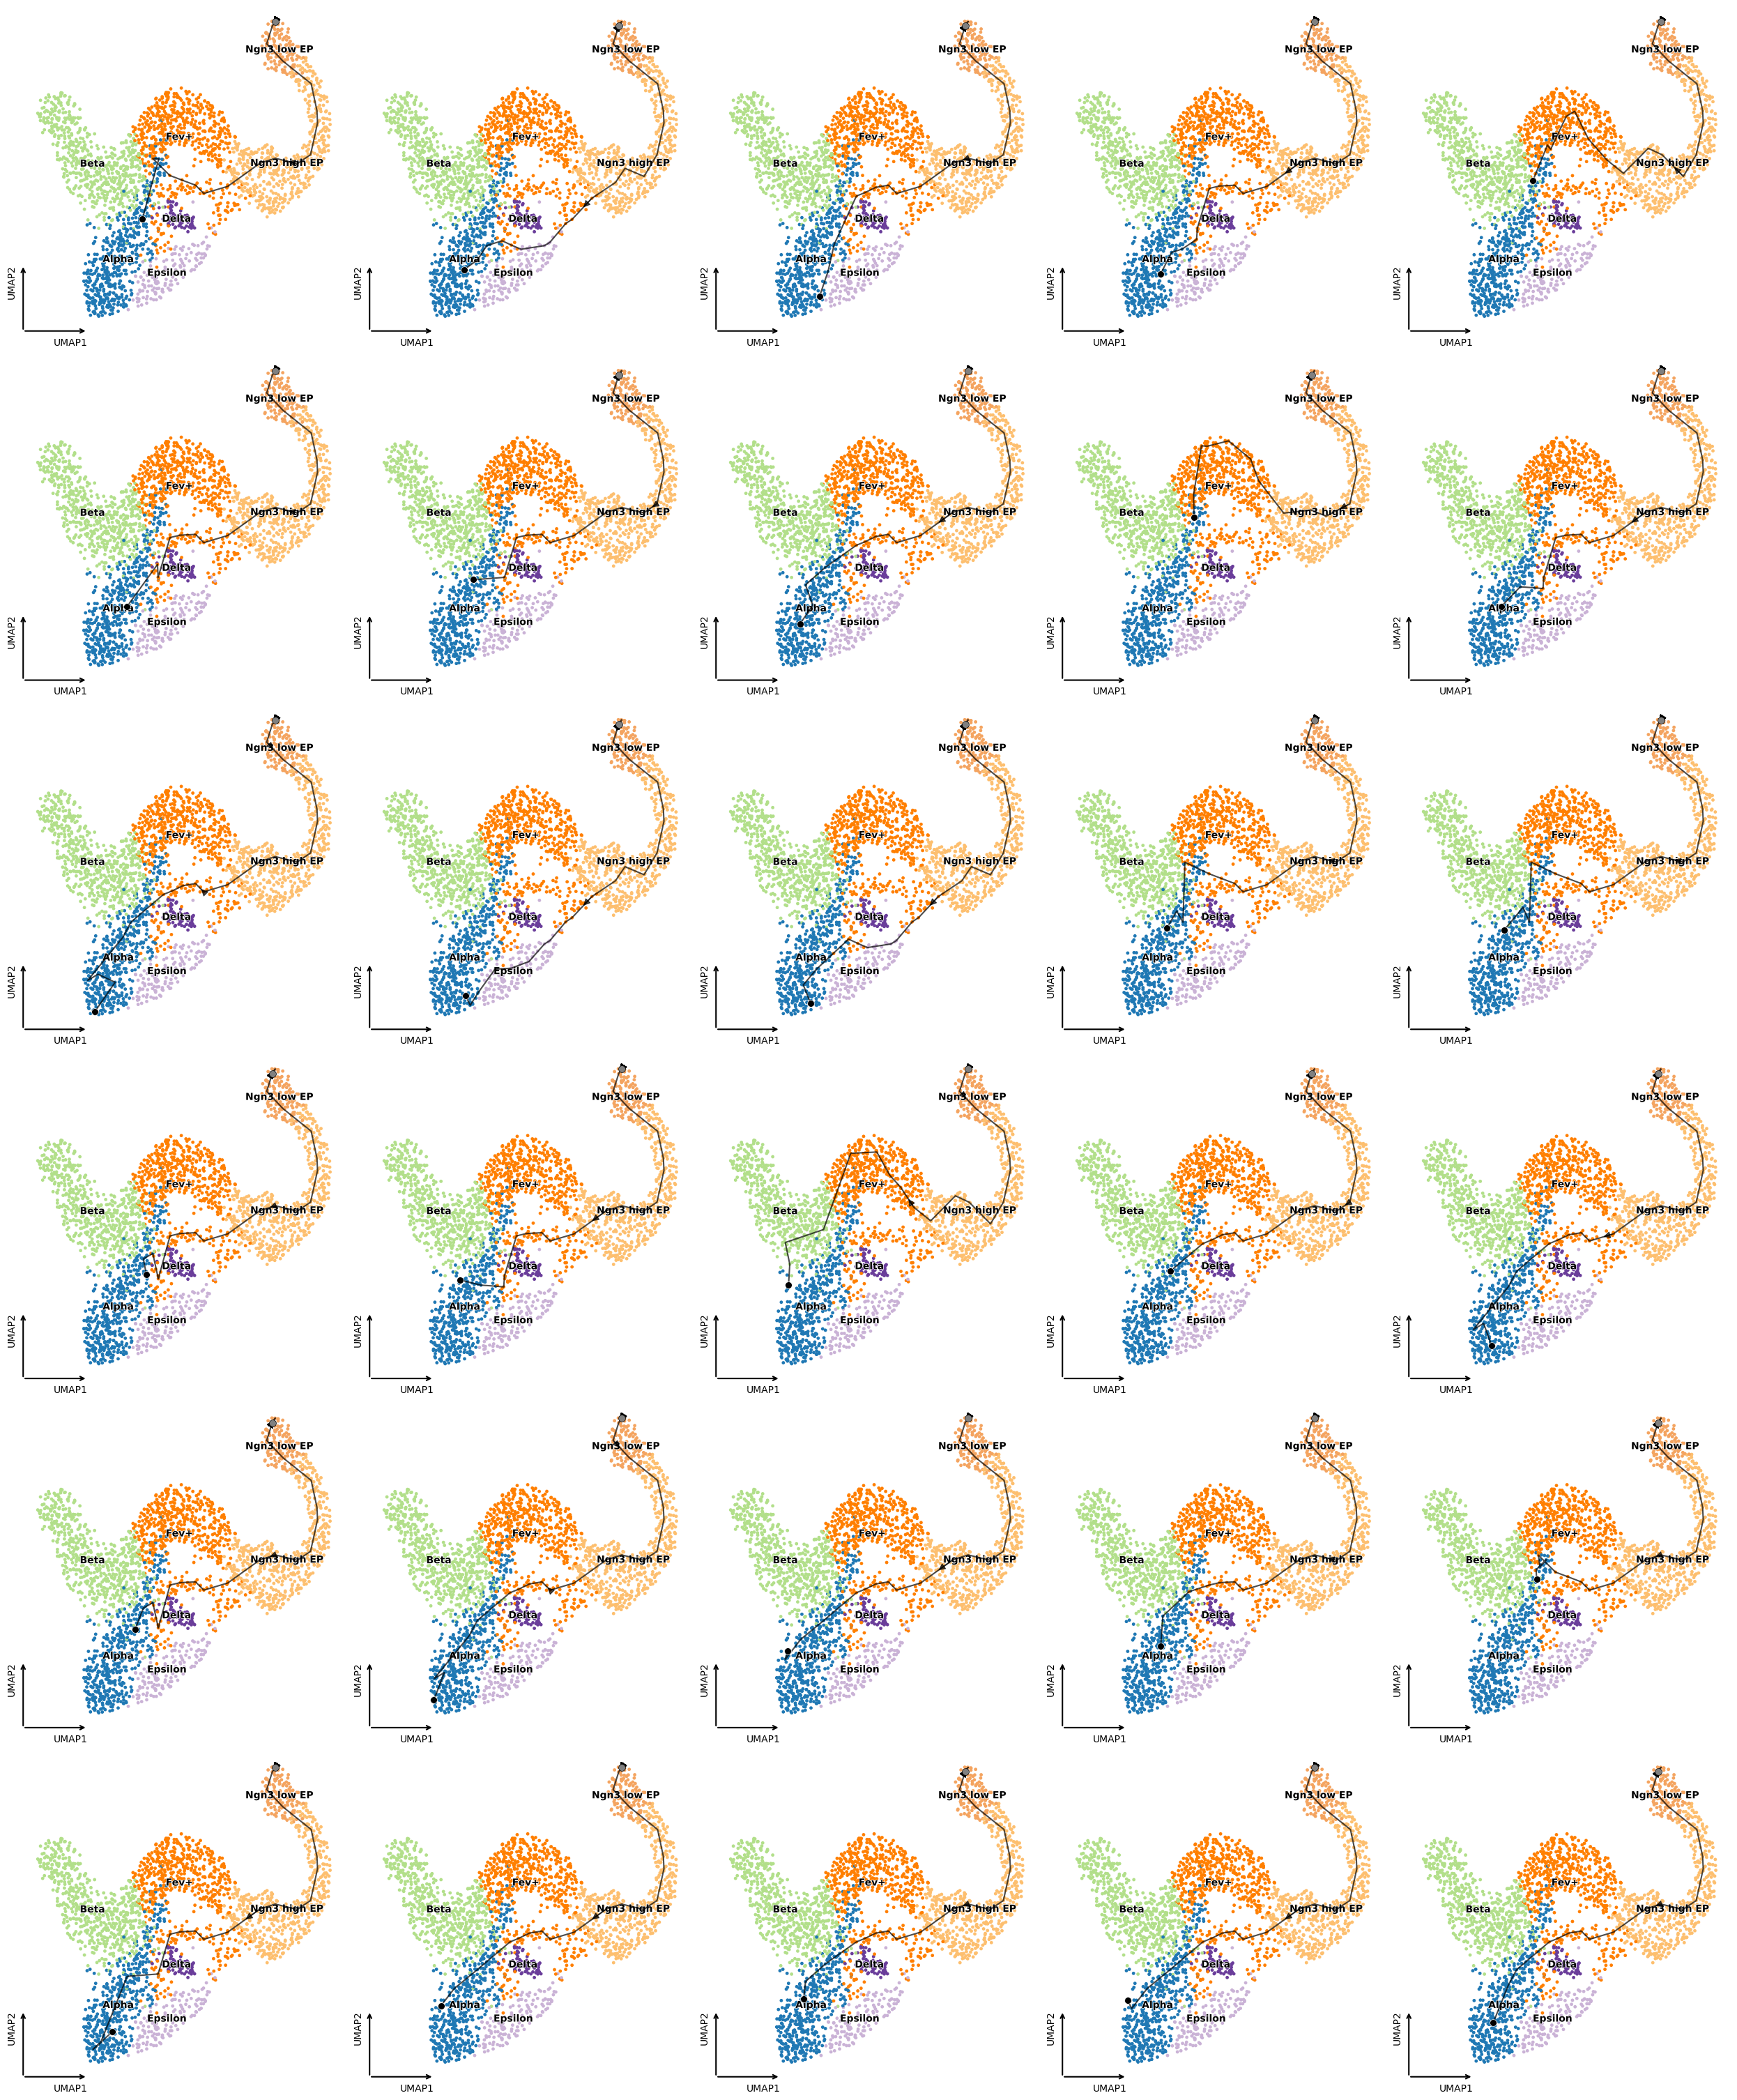

In [5]:
n = 30
cols = 5
rows = n // 5 + 1
s = 5
fig, axes = plt.subplots(rows, cols, figsize=(s*cols,s*rows))
axes = axes.flatten()

for i in range(n):
    axes[i] = velot.pl.trajectories(
        adata, color=clusters_key, line_width=1.5, line_style="-", arrow_frequency=10, arrow_size=15,
        show=show, basis="umap", trajectory_ids=[i], ax=axes[i]
    )

# Hide unused subplots
for j in range(n, len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()

In [ ]:
velot.pl.trajectories(
    adata, color=clusters_key, trajectory_ids=1, line_width=1.5, line_style="-", arrow_frequency=10, arrow_size=15,
    basis="umap", show=show, save=save, save_path=f"{figures_path}/figure2_i_{start_cluster.lower()}.png")

<Axes: >